In [11]:
import json
import matplotlib.pyplot as plt
import tifffile
import numpy as np
from tifffile import imread, imwrite
from scipy.ndimage import map_coordinates
from tifffile import TiffWriter


def shift_zstack(zstack_params,zstack_in):

    """
    Shift images in zstack by dx and dy to compensate for drift due objective angle.

    Parameters:
    - zstack_params: Path to a JSON file containing z-stack parameters.
    """
    # Load parameters from the JSON file
    with open(zstack_params, 'r') as file:
        params = json.load(file)

    zstack_params = params['zstack_shift']  # Get the zstack_shift parameters
    Ch = zstack_params['Ch']
    alpha = zstack_params['alpha']
    beta = zstack_params['beta']
    step = zstack_params['step']
    micron_per_pixel = zstack_params['micron_per_pixel']
    Nx = zstack_params['Nx']
    Ny = zstack_params['Ny']
    Nz = zstack_params['Nz']

    # Compute shifts in microns
    dx = np.tan(np.radians(alpha)) * step
    dy = np.tan(np.radians(beta)) * step

    # Initialize empty array for shifted images
    # 
    V_shifted = np.zeros((Nz, Ny, Nx), dtype=np.uint16)

    # Load and shift images
    for iz in range(Nz):
        filename_temp = f"{zstack_in}/{zstack_in.split('/')[-1]}_Cycle00001_Ch{Ch}_{iz + 1:06d}.ome.tif"
        V = imread(filename_temp)
        print(filename_temp)

        dxi = dx * (iz - Nz // 2)
        dyi = dy * (iz - Nz // 2)

        # Create a grid for the shifted image
        X, Y = np.meshgrid(np.arange(Nx) * micron_per_pixel - dxi, np.arange(Ny) * micron_per_pixel - dyi)

        # Interpolate the image on the new grid
        coordinates = np.array([Y.ravel() / micron_per_pixel, X.ravel() / micron_per_pixel])
        V_shifted[iz] = map_coordinates(V, coordinates, order=1, mode='nearest').reshape(Ny, Nx)

    # Normalize and save the shifted images
    zstack_out = f"{zstack_in}/zstack4_shifted1.tif"
    V_shifted = (V_shifted / V_shifted.max() * 255)
    V_shifted=V_shifted.astype(np.uint8)

    with TiffWriter(zstack_out, bigtiff=True) as writer:
        for iz in range(Nz):
            writer.write(V_shifted[iz])





In [12]:
shift_zstack('D:/Analysis_2P/Analysis_2P/Mesmerize/parameters/params_zshift_default.json',"D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002")

<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
c:\Users\Kyle\anaconda3\envs\mescore\lib\site-packages\tifffile\tifffile.py:19492: RuntimeWarning: invalid value encountered in divide
  value = value[..., 0] / value[..., 1]
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year

D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000001.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000002.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000003.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000004.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000005.ome.tif


<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised

D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000006.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000007.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000008.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000009.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000010.ome.tif


<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised

...

D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000030.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000031.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000032.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000033.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000034.ome.tif


<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised

D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000035.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000036.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000037.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000038.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000039.ome.tif


<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading CreateTime raised ValueError('no datetime before year 1 (julianday=0)')
<tifffile.read_uic_tag> reading LastSavedTime raised ValueError('no datetime before year 1 (julianday=0)')


D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000040.ome.tif
D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/ZSeries-10022023-1300-002_Cycle00001_Ch2_000041.ome.tif


(41, 765, 765)


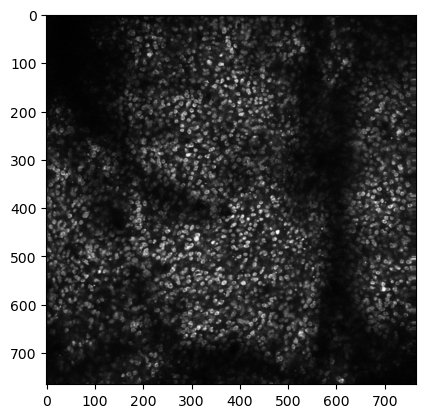

In [13]:
import numpy as np
from tifffile import TiffFile

Z_path = "D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002"
zstack_tiff1_file = TiffFile(Z_path + "/zstack4_shifted1.tif")

# Initialize an empty list to store the images
zstack_tiff1 = []
for page in zstack_tiff1_file.pages:
    zstack_tiff1.append(page.asarray())
zstack_tiff1 = np.stack(zstack_tiff1, axis=0)
zstack_tiff1_file.close()

# Check the shape of the loaded stack
print(zstack_tiff1.shape)
plt.imshow(zstack_tiff1[0], cmap='gray')
plt.show()

In [14]:
# Check the average intensity of the first image in the stack
import numpy as np
# zstack_tiff1
# np.average(zstack_tiff1[0])
for i in range(0, 10):
    print(np.average(zstack_tiff1[i]))



35.24852834379939
34.56321585714896
34.14940749284463
33.564376094664446
33.2155922935623
32.93844077064377
32.640668119099495
32.12874877183989
31.493693878422828
31.49208936733735


In [15]:
# matlab
np.average(zstack_tiff[0])
for i in range(0, 10):
    print(np.average(zstack_tiff[i]))

21.432023580674098
21.517756418471528
21.350918022982615
21.172036396257848
21.00965269768038
20.70562604126618
20.6559425861848
21.0882156435559
21.063068050749713
20.971103421760862


(41, 765, 765)


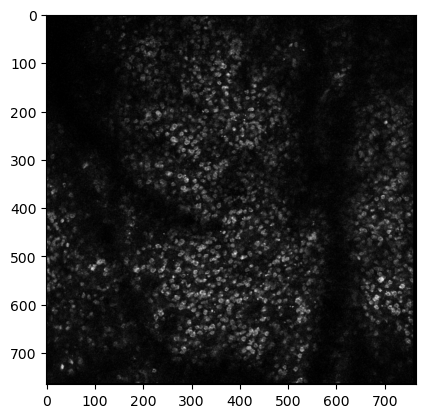

In [8]:
import numpy as np
from tifffile import TiffFile

Z_path = "D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002"
zstack_tiff_file = TiffFile(Z_path + "/zstack4_shifted.tif")

# Initialize an empty list to store the images
zstack_tiff = []
for page in zstack_tiff_file.pages:
    zstack_tiff.append(page.asarray())
zstack_tiff = np.stack(zstack_tiff, axis=0)
zstack_tiff_file.close()

# Check the shape of the loaded stack
print(zstack_tiff.shape)
plt.imshow(zstack_tiff[0], cmap='gray')
plt.show()